<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris%20-%20DAMA61_final2026_problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>
<h3 style="text-align:center;"> FINAL EXAM PROBLEM 2</h3>
<hr>

## Problem 2

We are going to utilize 2D Convolutional Neural Networks (CNN) to classify an **image dataset**. The **CIFAR-10** color image classification dataset can be loaded directly from `keras.datasets`. The dataset natively contains 32x32 pixel images with 3 color channels (RGB) across 10 object classes.

1. Load the CIFAR-10 dataset. Combine the default train and test splits into a single unified dataset, keep only the first **10,000** observations, normalize the pixel feature values to the range [0, 1], and ensure the input shape is appropriately formatted as a 4D tensor for a 2D CNN. **[10%]**

2. Split the 10,000 observations into a training (60%), a validation (10%), and a test (30%) set using `random_state=42`. You must perform a **stratified split** to maintain identical class distributions between the sets. Verify this by printing the class distributions for all three sets. Convert the target labels appropriately for multi-class classification. **[15%]**

3. Build a sequential 2D CNN with the following architecture:

    **Feature extractor part**:
    * A 2D convolutional layer of 8 filters of size 7 by 7
    * An Average Pooling layer of size 2 by 2
    * A 2D convolutional layer of 16 filters of size 5 by 5
    * An Average Pooling layer of size 2 by 2
    * A 2D convolutional layer of 32 filters of size 3 by 3

    All convolutional layers should maintain the spatial dimensions (height and width) using zero padding (`padding='same'`) and should have a stride of 1.

    **Classifier part**:
    * A `Flatten` layer to transition from 2D feature maps to a 1D vector
    * A fully connected (Dense) layer with 128 units
    * A fully connected (Dense) layer with 64 units
    * The output layer

    Both hidden fully connected layers should be preceded by a `Dropout` layer with a 30% rate. All Convolutional and Fully Connected hidden layers should use the `ReLU` activation function. The output layer should have the appropriate activation function and unit count for a 10-class classification problem.

    After you create the model, display its summary and note the total number of trainable parameters. **[25%]**

4. Compile the model with the `Adam` optimizer, use accuracy as the metric, and select the appropriate loss function that matches your target label format from Step 2. Create an early stopping callback that monitors validation accuracy with a patience of 3, reverting to the best weights upon stopping. Allow the model to train for up to 100 epochs with a batch size of 32. What is the final validation accuracy? **[25%]**

5. Plot the history of the loss and the accuracy for both the training and validation sets on a single graph. Comment on your results (e.g., check for overfitting or underfitting). **[10%]**

6. Plot the confusion matrix for the test set. Which pairs of object classes tend to cause the most confusion? Calculate the test set accuracy. Was the validation set accuracy a good approximation of performance? **[5%]**

7. For each test instance, calculate the model's confidence in its predicted class, defined as the maximum predicted probability from the output layer. Report the average confidence for the correctly classified test instances versus the incorrectly classified test instances. Plot the distribution of prediction confidence for correct and incorrect predictions on a histogram. Comment on whether the model tends to be less confident when it makes mistakes. **[10%]**

In [60]:
# import the needed packages
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [32]:
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

In [33]:
# Combine train and test to split as 60/10/30
X_full = np.concatenate([x_train_full, x_test], axis=0)
y_full = np.concatenate([y_train_full, y_test], axis=0)

print("Full dataset:", X_full.shape, y_full.shape)

Full dataset: (60000, 32, 32, 3) (60000, 1)


In [34]:
# keep only the first 10,000 observations and normalize to 0, 1
X = X_full[:10000].astype("float32") / 255.0
y = y_full[:10000]

In [35]:
# perform a stratified split of 60/10/30

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    train_size=0.60,
    stratify=y,
    random_state=42
)

In [36]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.75,
    stratify=y_temp,
    random_state=42
)

In [37]:
# validate proper splitting
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(6000, 32, 32, 3)
(1000, 32, 32, 3)
(3000, 32, 32, 3)


In [38]:
# Convert the target labels appropriately (target values into one-hot vectors)
y_train = tf.keras.utils.to_categorical(y_train, num_classes = 10)
y_valid = tf.keras.utils.to_categorical(y_valid, num_classes = 10)
y_test  = tf.keras.utils.to_categorical(y_test,  num_classes = 10)

In [40]:
# build the requested a sequential 2D CNN

def build_model():

    model = Sequential()
    model.add(InputLayer(shape=(32, 32, 3)))
    model.add(Conv2D(8, (7, 7), strides=1, padding="same", activation="relu"))
    model.add(AveragePooling2D(pool_size=(2, 2)))
    model.add(Conv2D(16, (5, 5), strides=1, padding="same", activation="relu"))
    model.add(AveragePooling2D(pool_size=(2, 2)))
    model.add(Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"))

    model.add(Flatten())
    model.add(Dropout(0.30))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.30))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [41]:
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 8, 8, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,218 (1.07 MB)

 Trainable params: 280,218 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# total number of trainable parameters
model.count_params()

280218

In [47]:
# compli the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# early stopping
early_stopping_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping_cb],
    verbose=1
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5237 - loss: 1.3361 - val_accuracy: 0.4760 - val_loss: 1.4458
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5395 - loss: 1.2733 - val_accuracy: 0.4810 - val_loss: 1.4233
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5575 - loss: 1.2344 - val_accuracy: 0.4820 - val_loss: 1.4451
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5733 - loss: 1.1876 - val_accuracy: 0.4920 - val_loss: 1.4513
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5925 - loss: 1.1347 - val_accuracy: 0.4860 - val_loss: 1.4796
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6015 - loss: 1.0984 - val_accuracy: 0.4830 - val_loss: 1.4931
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6317 - loss: 1.0372 - val_accuracy: 0.4960 - val_loss: 1.4710
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6363 - loss: 1.0011 - val_ac

In [51]:

best_val_accuracy = max(history.history["val_accuracy"])

print("Best Validation Accuracy:", best_val_accuracy)

Best Validation Accuracy: 0.5120000243186951


The model achieved a best validation accuracy of 51%. This is reasonable taking into consideration we only took 10.000 samples from the dataset and our model architecture is quite simple

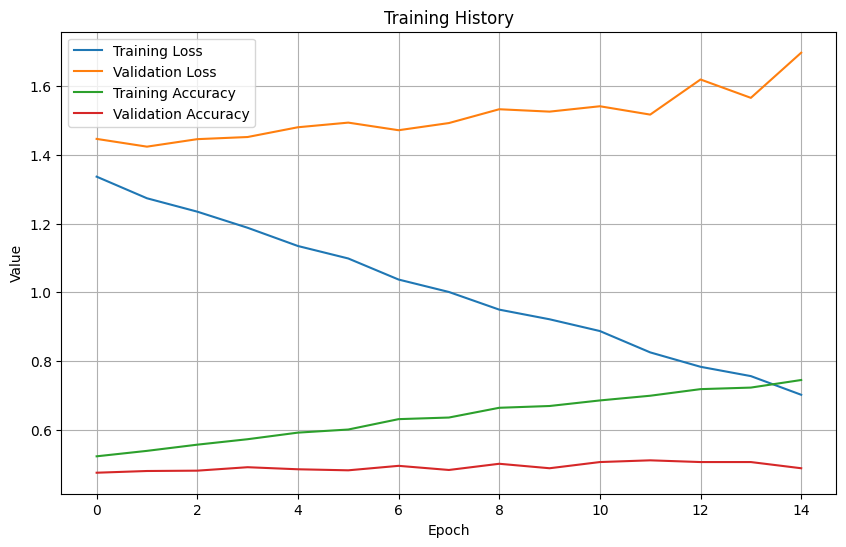

In [52]:
plt.figure(figsize=(10,6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training History")

plt.legend()
plt.grid(True)

plt.show()

From the plot it is very clear that we have overfitting, since the training accuracy increases steadily while the training loss decreases throughout the training process, but in the same time the validation accuracy improves only slightly and then stabilizes around 50%, while the validation loss keeps increasing

It is clear that the model continues learning the training data but does not  generalize well to unseen data.

In [53]:
# predictions for the test set

y_pred_prob = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [54]:
# convert to class labbels

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

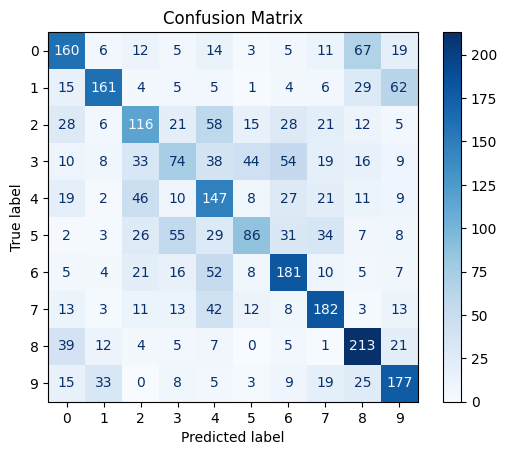

In [58]:
# one-hot encoded labels back to class labels

y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



The confusion matrix indicates that the most frequently confused class pairs are:
1. Class 0 and Class 8 (67),
2. Class 1 and Class 9 (62),
3. Class 2 and Class 4 (58)
These pairs correspond to the largest off-diagonal values in the confusion matrix.

In [59]:
# Calculate test accuracy
test_accuracy = accuracy_score(y_true, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.499


The validation accuracy was a good approximation of performance because it was very close to the test accuracy (51.2% vs 49.9%).